## Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import os
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


##  Dataset Definition

In [ ]:
class FruitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Directory {root_dir} not found.")

        self.class_names = sorted([f for f in os.listdir(root_dir)
                                   if os.path.isdir(os.path.join(root_dir, f))])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}

        for class_idx, class_name in enumerate(self.class_names):
            class_dir = os.path.join(root_dir, class_name)
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.images.append(os.path.join(class_dir, img_file))
                    self.labels.append(class_idx)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

class ApplyTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y
    def __len__(self): return len(self.subset)

## Data Loading

In [ ]:
dataset_path = 'FRUIT-16K' # Ensure this matches your folder name

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dataset = FruitDataset(dataset_path)
train_size = int(0.7 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    base_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(ApplyTransform(train_subset, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(ApplyTransform(val_subset, test_transform), batch_size=32, shuffle=False)
test_loader = DataLoader(ApplyTransform(test_subset, test_transform), batch_size=32, shuffle=False)

## Data Visualization

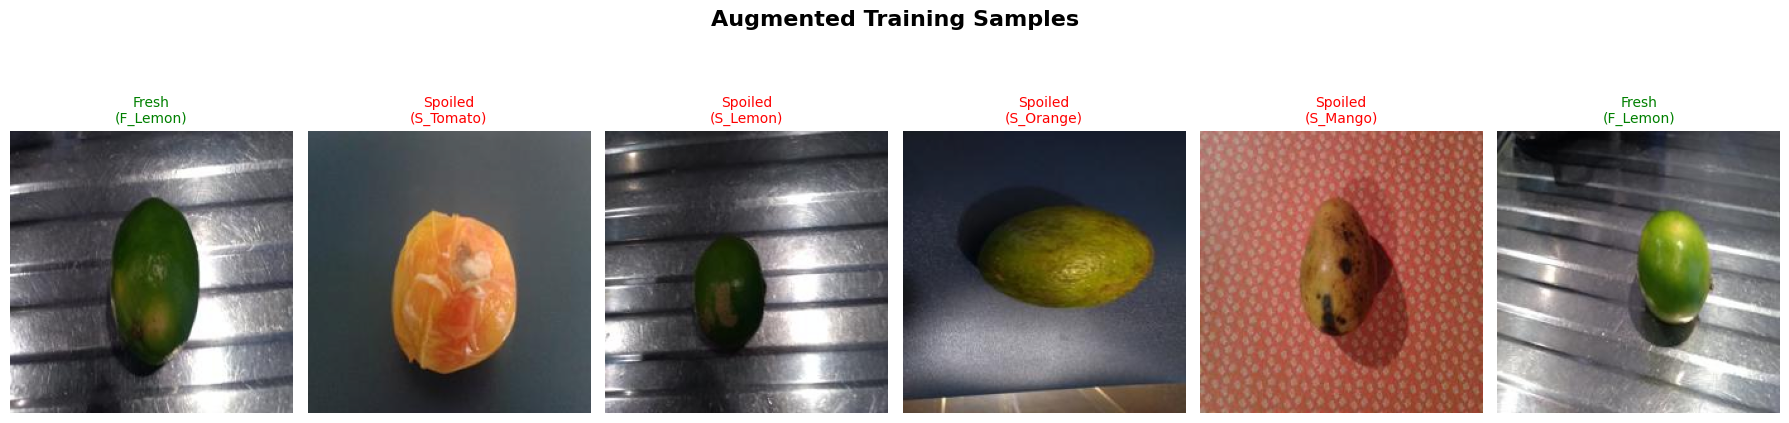

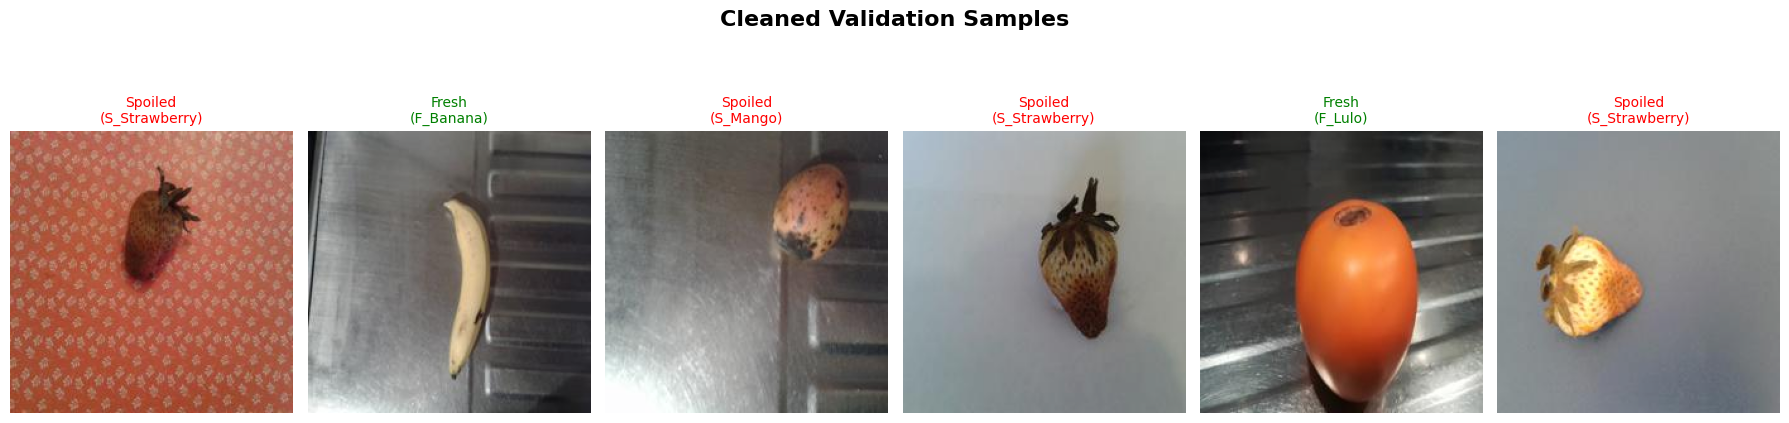

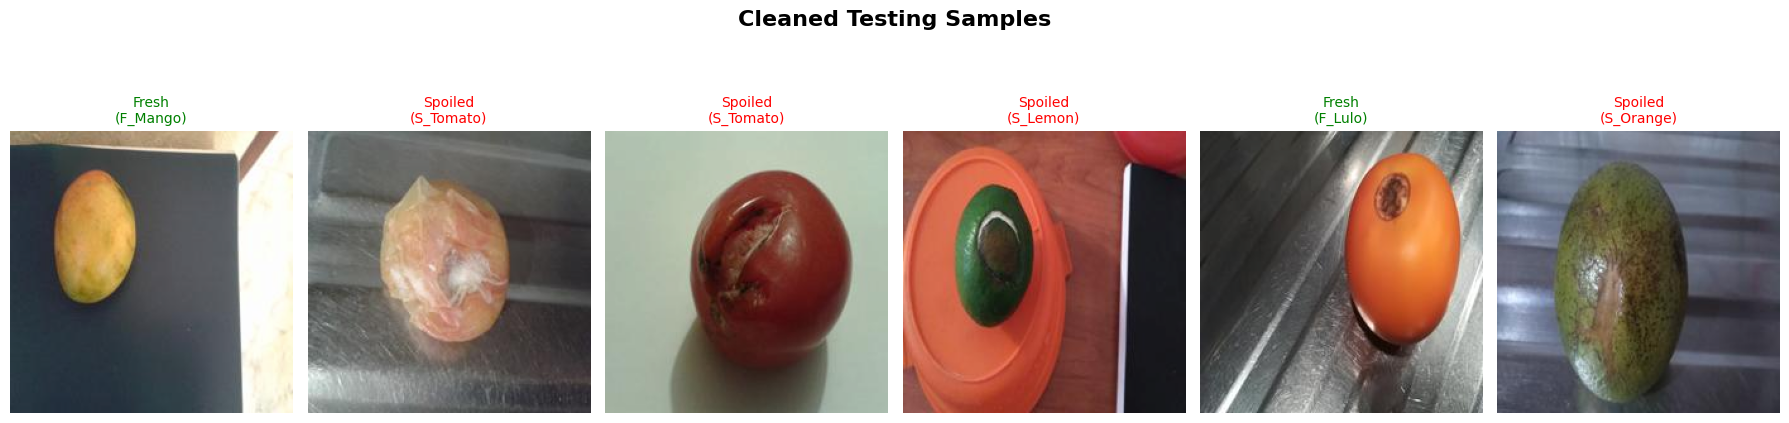

In [ ]:
import numpy as np

def visualize_dataset_samples(loader, title, class_names, n=6):
    # Grab one batch from the loader
    images, labels = next(iter(loader))

    def get_label_text(idx):
        name = class_names[idx]
        return "Fresh" if name.startswith('F_') else "Spoiled"

    plt.figure(figsize=(18, 5))
    plt.suptitle(title, fontsize=16, fontweight='bold')

    # ImageNet denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(min(n, len(images))):
        # Convert tensor to image format (HWC) and denormalize
        img = images[i].numpy().transpose((1, 2, 0))
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)

        binary_name = get_label_text(labels[i])
        original_folder = class_names[labels[i]]
        color = 'green' if binary_name == "Fresh" else 'red'

        plt.title(f"{binary_name}\n({original_folder})", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- EXECUTION ---
# Visualize all three sets
visualize_dataset_samples(train_loader, "Augmented Training Samples", base_dataset.class_names)
visualize_dataset_samples(val_loader, "Cleaned Validation Samples", base_dataset.class_names)
visualize_dataset_samples(test_loader, "Cleaned Testing Samples", base_dataset.class_names)

## Transfer Learning Model - ResNet50

In [ ]:
# Load pre-trained ResNet50
model = models.resnet50(weights='DEFAULT')

# Freeze all layers (don't update weights during backprop)
for param in model.parameters():
    param.requires_grad = False

# Replace the final Fully Connected layer (fc)
# ResNet50's original fc layer has 2048 input features
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # Binary: Fresh vs Spoiled

model = model.to(device)

print("ResNet50 loaded and modified for Binary Classification.")

ResNet50 loaded and modified for Binary Classification.


## Training Logic

In [ ]:
def get_binary_label(label_idx, dataset):
    class_name = dataset.class_names[label_idx]
    return 0 if class_name.startswith('F_') else 1

# Mapping table for quick binary lookup on the GPU
class_to_binary = torch.tensor([get_binary_label(i, base_dataset) for i in range(len(base_dataset.class_names))], device=device)

criterion = nn.CrossEntropyLoss()
# Still only optimizing the 'fc' layer for efficiency
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

def train_transfer_model(epochs=10):
    best_acc = 0.0
    print(f"{'Epoch':<8} | {'Loss':<8} | {'Train Acc':<10} | {'Val Acc':<10}")
    print("-" * 50)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            binary_labels = class_to_binary[labels]

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, binary_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += binary_labels.size(0)
            correct += predicted.eq(binary_labels).sum().item()

        # Calculate Training Metrics
        avg_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation Phase
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                binary_labels = class_to_binary[labels]
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += binary_labels.size(0)
                val_correct += predicted.eq(binary_labels).sum().item()

        val_acc = 100. * val_correct / val_total

        # Print Statement
        print(f"{epoch+1:02d}    | {avg_loss:.4f}   | {train_acc:.2f}%    | {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'resnet50_fruit_model.pt')
            print(f"--> New Best Validation Accuracy! Model Saved.")

# Run the training
train_transfer_model(epochs=7)

Epoch    | Loss     | Train Acc  | Val Acc   
--------------------------------------------------
01    | 0.2882   | 90.48%    | 95.17%
--> New Best Validation Accuracy! Model Saved.
02    | 0.1483   | 95.50%    | 96.83%
--> New Best Validation Accuracy! Model Saved.
03    | 0.1136   | 96.75%    | 96.92%
--> New Best Validation Accuracy! Model Saved.
04    | 0.0932   | 97.38%    | 97.17%
--> New Best Validation Accuracy! Model Saved.
05    | 0.0821   | 97.72%    | 97.42%
--> New Best Validation Accuracy! Model Saved.
06    | 0.0759   | 97.79%    | 97.96%
--> New Best Validation Accuracy! Model Saved.
07    | 0.0714   | 97.96%    | 98.00%
--> New Best Validation Accuracy! Model Saved.


In [ ]:
def evaluate_test_set():
    # Load the best saved weights
    model.load_state_dict(torch.load('resnet50_fruit_model.pt'))
    model.eval()

    test_correct = 0
    test_total = 0

    print("--- Starting Final Test Set Evaluation ---")

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            # Map original labels (0-N) to binary (0-1) using our pre-defined tensor
            binary_labels = class_to_binary[labels.to(device)]

            outputs = model(images)
            _, predicted = outputs.max(1)

            test_total += binary_labels.size(0)
            test_correct += predicted.eq(binary_labels).sum().item()

    final_test_acc = 100. * test_correct / test_total
    print(f"\nFINAL TEST RESULTS")
    print("-" * 30)
    print(f"Accuracy:           {final_test_acc:.2f}%")
    print(f"Total Test Images:  {test_total}")
    print(f"Correct:            {test_correct}")
    print(f"Errors:             {test_total - test_correct}")

# Run the evaluation
evaluate_test_set()

--- Starting Final Test Set Evaluation ---

FINAL TEST RESULTS
------------------------------
Accuracy:           98.12%
Total Test Images:  2400
Correct:            2355
Errors:             45


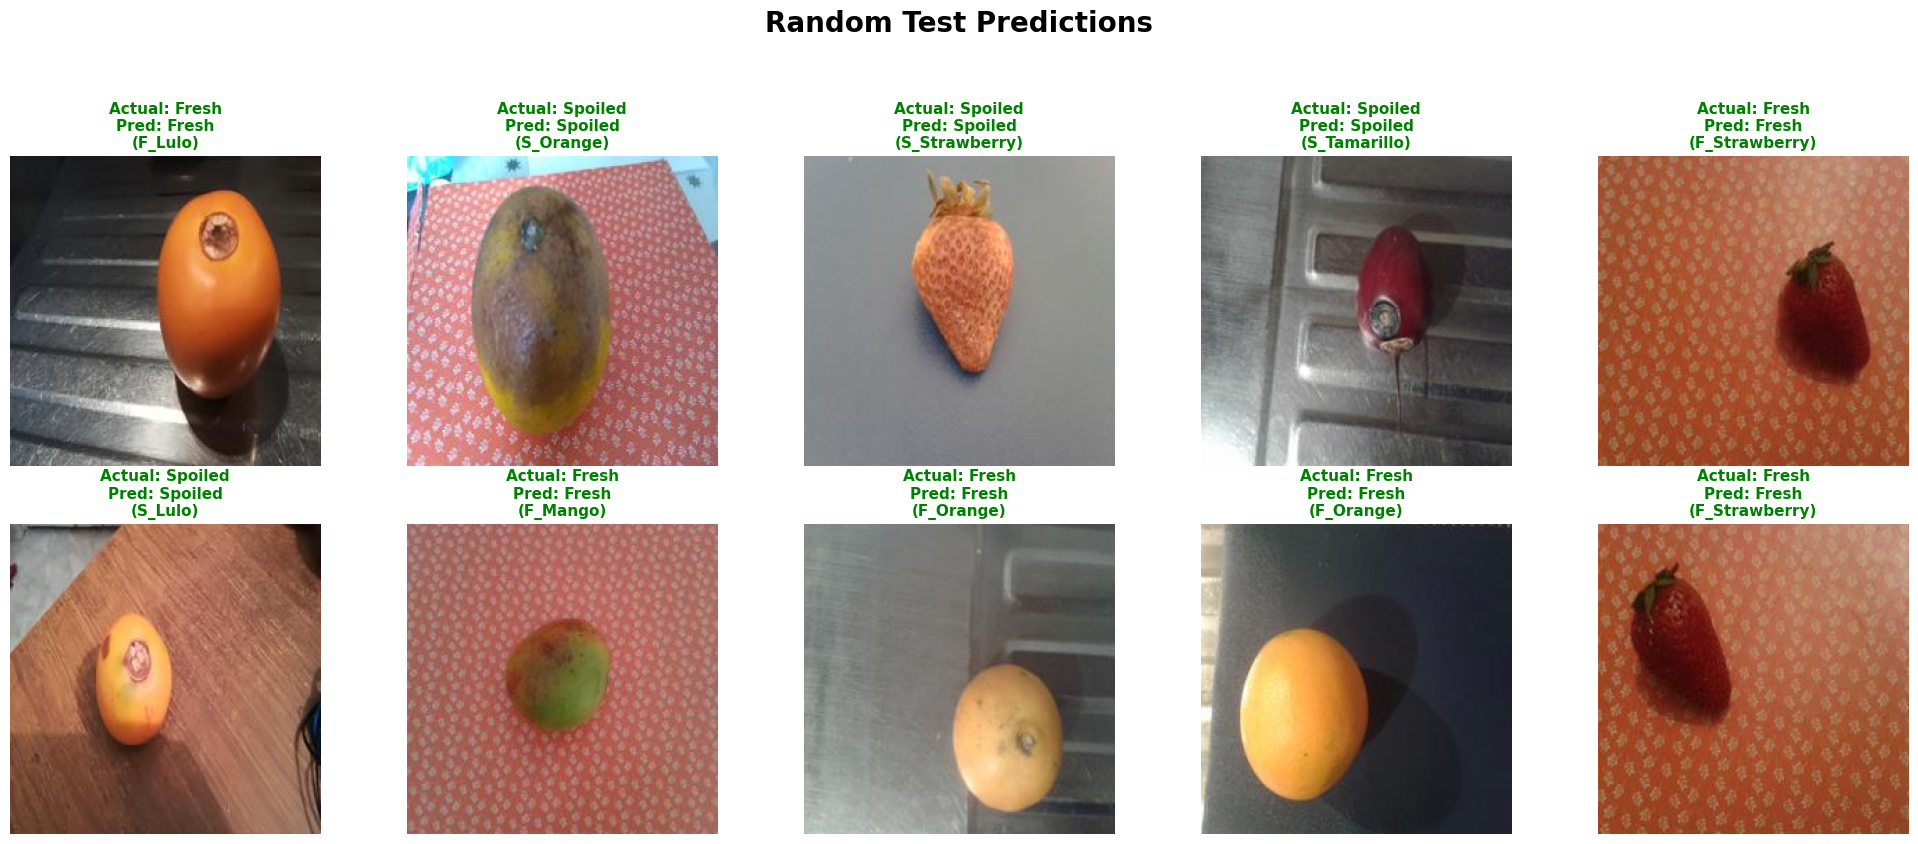

In [ ]:
import random

def visualize_test_predictions(n=10):
    model.eval()

    # We use ApplyTransform on the test_subset so we get the resized/normalized tensors
    processed_test_data = ApplyTransform(test_subset, test_transform)

    # Select random indices
    indices = random.sample(range(len(processed_test_data)), n)

    plt.figure(figsize=(20, 8))
    plt.suptitle("Random Test Predictions", fontsize=20, fontweight='bold', y=1.05)

    # Denormalization parameters for ResNet
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, label_idx = processed_test_data[idx]

            # Predict
            input_tensor = img_tensor.unsqueeze(0).to(device)
            outputs = model(input_tensor)
            _, predicted = outputs.max(1)

            # Determine Labels
            actual_binary = get_binary_label(label_idx, base_dataset)
            pred_binary = predicted.item()

            actual_text = "Fresh" if actual_binary == 0 else "Spoiled"
            pred_text = "Fresh" if pred_binary == 0 else "Spoiled"
            folder_name = base_dataset.class_names[label_idx]

            # Formatting
            color = 'green' if actual_binary == pred_binary else 'red'

            # Denormalize for plotting
            img_show = img_tensor.cpu() * std + mean
            img_show = torch.clamp(img_show, 0, 1).permute(1, 2, 0).numpy()

            plt.subplot(2, 5, i + 1)
            plt.imshow(img_show)
            plt.title(f"Actual: {actual_text}\nPred: {pred_text}\n({folder_name})",
                      color=color, fontsize=11, fontweight='bold')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 10 random samples from the test set
visualize_test_predictions(n=10)